# 03 · Magnetic navigation: EKF vs particle filter
Full `run_simple_nav` pipeline: T-L compensation, drifting-INS simulation, EKF and PF navigation via map matching. The filters are interchangeable (`NavFilter` protocol).

In [1]:
import os, sys
while not os.path.isdir('magnavlab') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print('repo:', os.getcwd())

repo: /home/wpalka/magnav


In [2]:
from magnavlab.experiments import SimpleNavConfig, run_simple_nav
from IPython.display import Image
out = run_simple_nav(SimpleNavConfig(make_plots=True))
for name, m in out['metrics'].items():
    print(f"{name:4s} DRMS={m['drms']:7.1f} m  CEP50={m['cep50']:6.1f}  "
          f"CEP95={m['cep95']:6.1f}  max={m['max']:7.1f}")

INS  DRMS=  575.6 m  CEP50= 501.9  CEP95= 941.5  max=  988.9
EKF  DRMS=  101.3 m  CEP50=  92.1  CEP95= 158.8  max=  242.0
PF   DRMS=  293.4 m  CEP50= 294.5  CEP95= 400.9  max=  412.7


## Position error over time

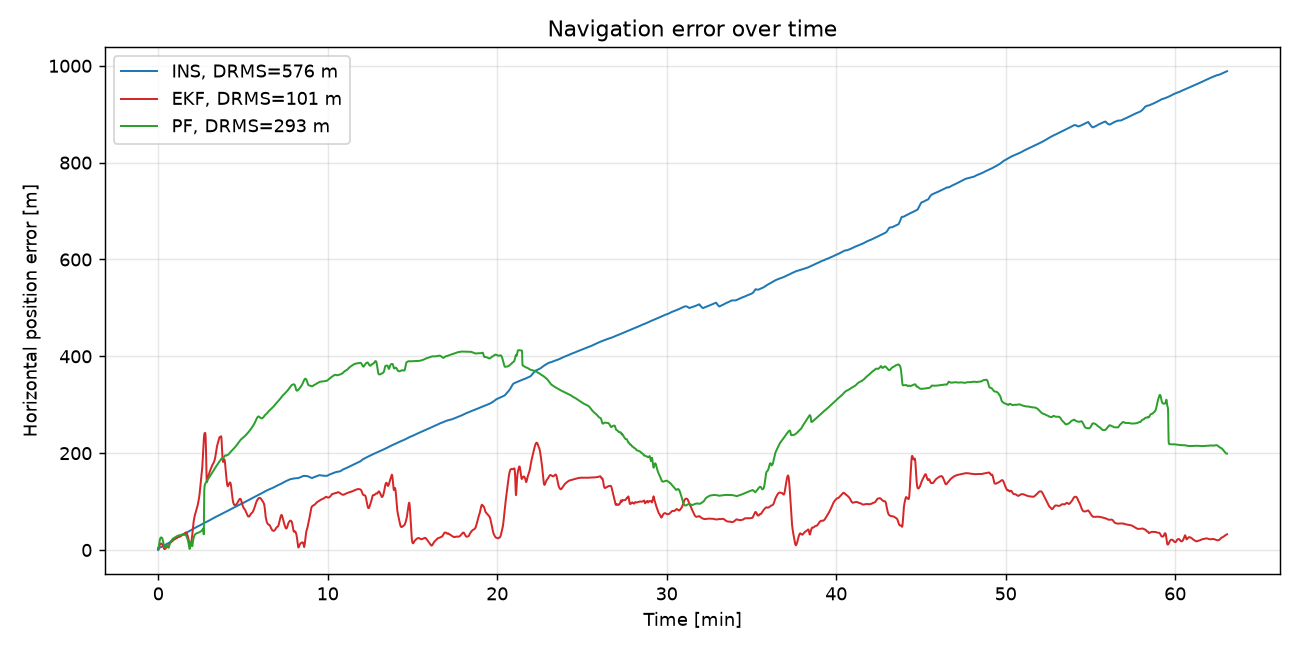

In [3]:
Image('outputs/simple_position_error.png')

## Trajectories on the map

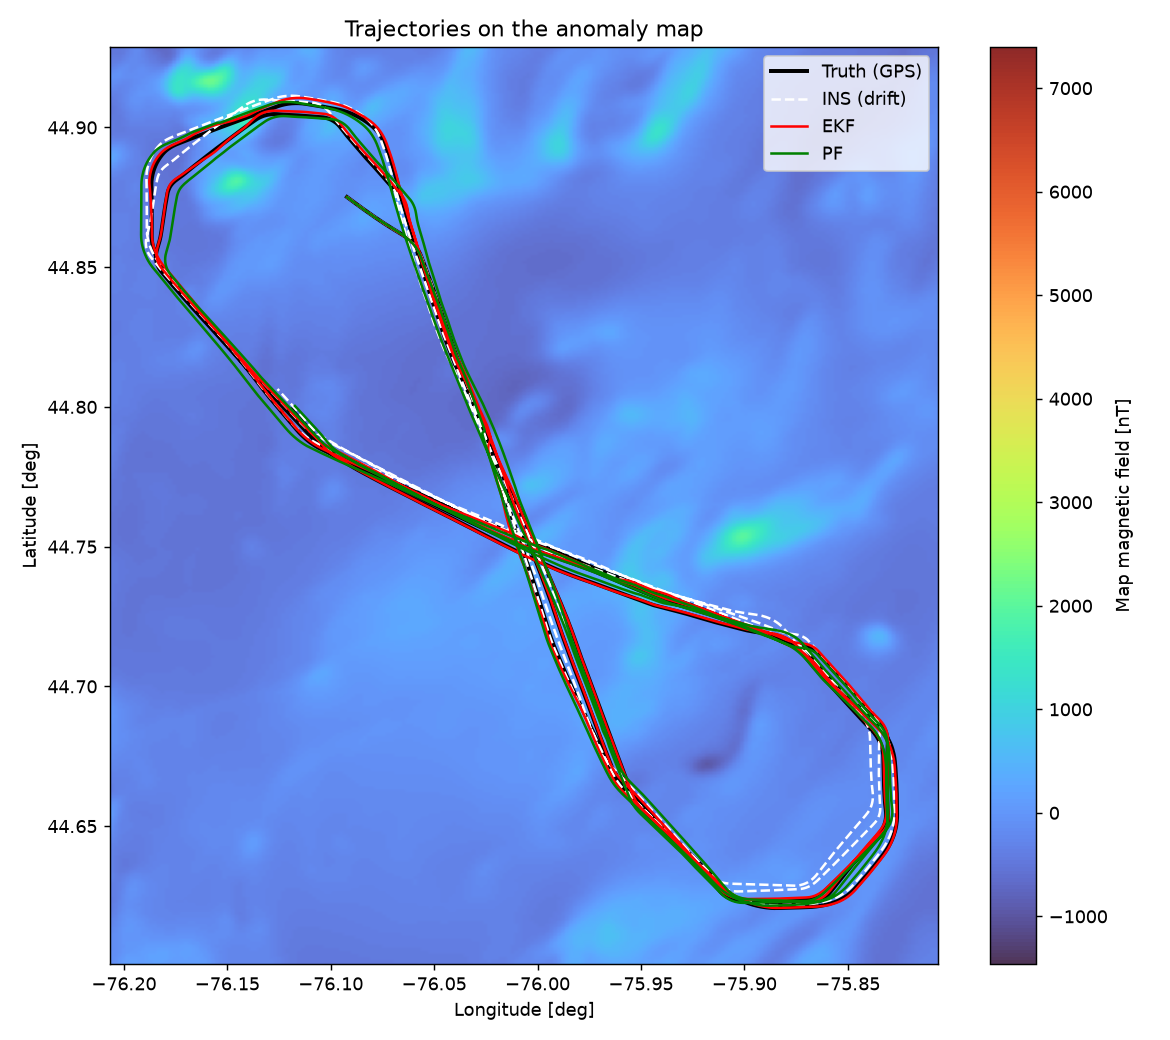

In [4]:
Image('outputs/simple_tracks.png')

Swapping the filter/calibrator comes down to replacing a component, e.g.:
```python
run_simple_nav(SimpleNavConfig(calibrator='mapbased', nav_signal='stinger'))
```